In [8]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate
load_dotenv()

True

In [23]:
model=ChatGoogleGenerativeAI(model="gemini-3.6-flash",temperature=0.2,max_output_tokens=440)

In [10]:
class LLM(TypedDict):
    input_text: str
    output_text: str

In [11]:
def llm_qa(state: LLM)->LLM:
    input_text = state["input_text"]
    prompt_template = PromptTemplate.from_template("Answer the following question: {question}")
    prompt = prompt_template.format(question=input_text)
    output_text = model.invoke(prompt).content 
    state["output_text"] = output_text
    return state

In [15]:
graph=StateGraph(LLM)

graph.add_node("llm_qa",llm_qa)

graph.add_edge(START,"llm_qa")
graph.add_edge("llm_qa",END)

workflow=graph.compile()

In [24]:
initial_state={"input_text": "how far is moon from earth?"}
final_state=workflow.invoke(initial_state)
print(final_state)

/home/sanju/miniconda3/envs/mjolnir/lib/python3.11/site-packages/langchain_google_genai/chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


{'input_text': 'how far is moon from earth?', 'output_text': [{'type': 'text', 'text': '*Drafting Section 2 (The Range):*\n        Because the', 'extras': {'signature': 'EugLCuULARFNMg+GUankD/rIkPmzy1Xan+KC/DzZsGPcYbQDBciqR7gdoYLpmxEU7tyFU7boKAzsLCn9D1qnoPt/zCr4wBaEzsbW+0gESqOdU5dxeEQkHCqoys5P3lJXXGUXoeZt8crRlgQszHYsBXFaY8m6BvnR6StIHpbmOUMo3OT0+ErgQ9AGPTcL5SLrKfhI/f97sOmBiItU6w6rpRdodlYHz4vveJgEfl+X1yIisPm3mOmWTU2fTAs7V9WMSZloqBiUVedb6H724L/0tfP5MJQ3IwnvjLb3nKA9VHlBYHAn+nsomaIz/0ySTHYifdUQ/S6KBgCZtWzb5mDG09hZyyTB7LMenUCb9Y3k6/i38Saf6owjO+pKvqXQwVXVMXFDNZickxlFp6E9IqjQfSZv03A/VI4clhuFDKS8lSxZOeuh0t7bYmu/nRWn5N9kim0YHle3pmsu1xDxcEYnbwfzUGdaofcSmUQVIUbPyp2Gp3z/hLnlcKzKyYzr7549ZzmKQsJhzvmqbrha1SPlIsdjWD1iqQzHr6oafeGNXPbSm1rIMuVcu0qIuks2YlaCV7wGx495q+iaoaH/3dQy5pxaFMjXJ+MU/t8AZn2431ZxSwn2QYgvbg5L1RPGsa5WIQt4Jh5R4MjxTRc1OBwFYbtxKYbDYJD05KwiIkp1N0Z+r0AJkXj5LDCtsApzAbpF3mdYzapTkk2bcHa2xQg6JNplHTx+PEa+Brz3ErlwTkhxDEFXZUos8wGZx2oKSABsSD8j6+umNb7ksgXeVcRIeE5r4EWoi7CabK8DBKTnqJQLS71AnwvaZdMM2t/338

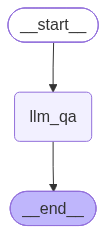

In [21]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())